In [1]:
import numpy as np
from sklearn.cluster import KMeans
from sklearn.mixture import GaussianMixture
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

In [2]:
test = np.load('connectivity-N1250-T10e06.npy')

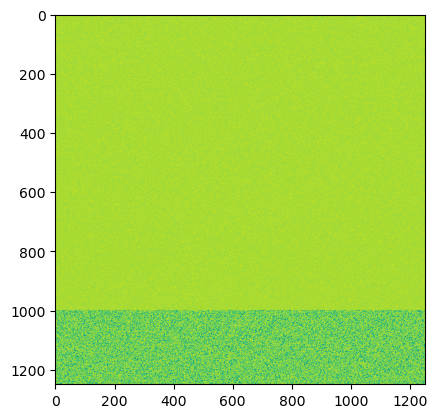

In [6]:
plt.imshow(test)

In [4]:
est= np.load('est_connectivity-N1250-T10e06.npy')

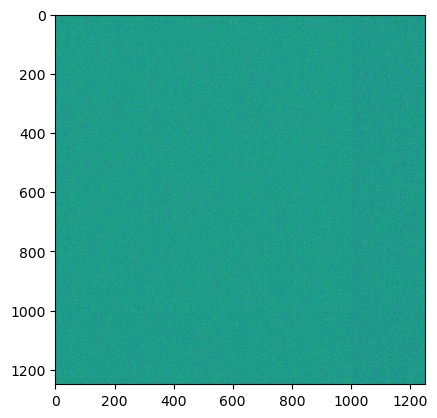

In [7]:
plt.imshow(est)

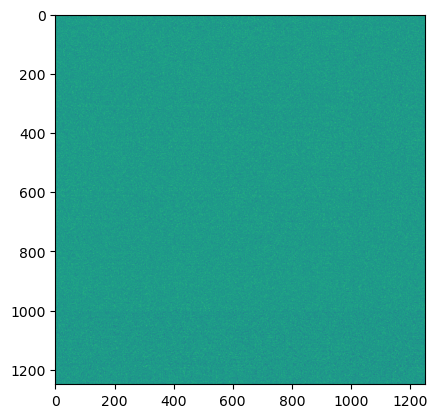

In [8]:
estt = est.T
plt.imshow(estt)

In [9]:
np.corrcoef(test.flatten(), estt.flatten())

array([[1.        , 0.22263483],
       [0.22263483, 1.        ]])

In [3]:
mat_gt_6 = np.load('data/connectivity-60e6-ms.npy')
mat_est_6 = np.load('data/est_conn_lag10-60e6-tau200-final_data.npy')
mat_gt_h5 = np.load('data/connectivity-h5-2.npy')
mat_est_h5 = np.load('data/est_connectivity-h5-2.npy')

In [40]:
mat_est_6.shape

(1250, 1250)

In [7]:
np.unique(mat_gt_6)

array([-48.,   0.,   8.])

In [9]:
np.unique(mat_est_6)

array([-0.14035538, -0.13497125, -0.13276942, ...,  0.04736467,
        0.0489308 ,  0.05140164])

In [89]:
values_est6 = mat_est_6.reshape(-1, 1)
#values_est_h5 = mat_est_h5.reshape(-1, 1)

In [90]:
kmeans = KMeans(n_clusters=3, random_state=42)
clusters = kmeans.fit_predict(values_est6)

In [91]:
cluster_centers = kmeans.cluster_centers_.ravel()
cluster_labels = np.unique(clusters)
cluster_sizes = [np.sum(clusters == label) for label in cluster_labels]

In [92]:
replaced_kmeans_matrix = np.vectorize(lambda x: cluster_centers[x])(clusters).reshape(mat_est_6.shape)

In [57]:
r100 = replaced_kmeans_matrix[1100, :]

In [58]:
np.unique_counts(r100)

UniqueCountsResult(values=array([-0.04962133, -0.003127  ,  0.0060514 ]), counts=array([ 25, 691, 534]))

In [63]:
c100 = replaced_kmeans_matrix[:, 200]

In [64]:
np.unique_counts(c100)

UniqueCountsResult(values=array([-0.003127 ,  0.0060514]), counts=array([725, 525]))

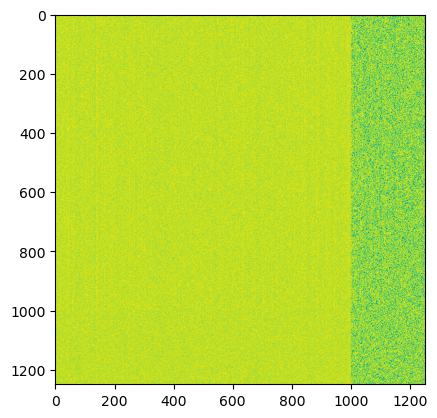

In [93]:
plt.imshow(replaced_kmeans_matrix)

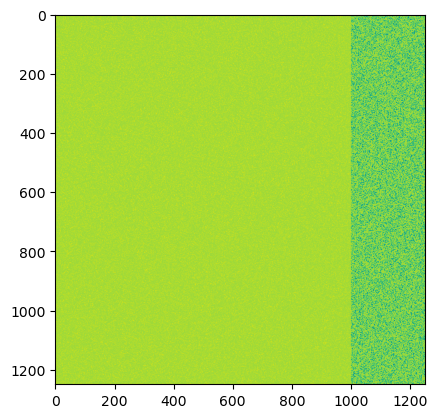

In [66]:
plt.imshow(mat_gt_6)

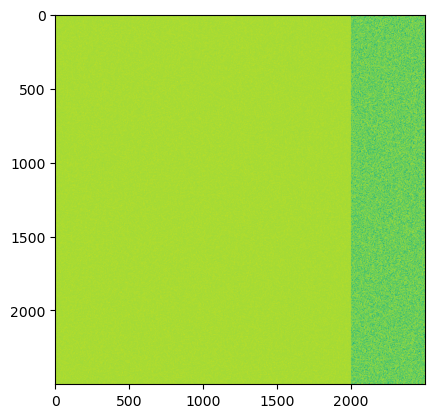

In [67]:
plt.imshow(mat_gt_h5)

In [74]:
cluster_centers

array([ 0.00011205,  0.00170382, -0.00147389])

In [32]:
print(cluster_labels)

[0 1 2]


In [33]:
cluster_sizes

[np.int64(648247), np.int64(29131), np.int64(885122)]

In [94]:
sorted_centers = np.argsort(cluster_centers.ravel())
class_mapping = {sorted_centers[2]: 'Excitatory', sorted_centers[1]: 'Unconnected', sorted_centers[0]: 'Inhibitory'}

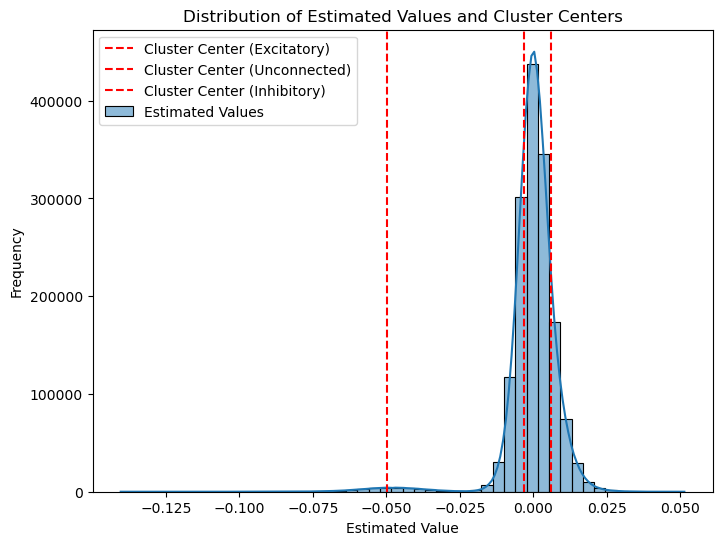

In [95]:
#classified_labels = np.vectorize(class_mapping.get)(clusters).reshape(mat_est_6.shape)

# Visualizing the distribution of estimated values and the assigned classes
plt.figure(figsize=(8, 6))
sns.histplot(values_est6, bins=50, kde=True, color='blue', label='Estimated Values')
for center, label in zip(cluster_centers, class_mapping.values()):
    plt.axvline(center, color='red', linestyle='--', label=f'Cluster Center ({label})')
plt.title('Distribution of Estimated Values and Cluster Centers')
plt.xlabel('Estimated Value')
plt.ylabel('Frequency')
plt.legend()
plt.show()


In [96]:


# Summary of analysis
analysis_summary_no_proportions = {
    'Cluster Centers': cluster_centers.ravel(),
    'Cluster Sizes': [np.sum(clusters == label) for label in cluster_labels],
    'Class Mapping': class_mapping
}

analysis_summary_no_proportions

{'Cluster Centers': array([ 0.0060514 , -0.04962133, -0.003127  ]),
 'Cluster Sizes': [np.int64(648247), np.int64(29131), np.int64(885122)],
 'Class Mapping': {np.int64(0): 'Excitatory',
  np.int64(2): 'Unconnected',
  np.int64(1): 'Inhibitory'}}

In [39]:
clustered_matrix = np.vectorize(lambda x: cluster_centers[x])(clusters).reshape(mat_est_6)

ValueError: maximum supported dimension for an ndarray is currently 64, found 1250

## Test the estimated network

### Topological properties

In [4]:
import networkx as nx
from collections import Counter
import community as community_louvain

In [116]:
# 1. Degree Distribution
def plot_degree_distribution(G):
    degrees = [G.degree(n) for n in G.nodes()]
    degree_count = Counter(degrees)
    deg, cnt = zip(*degree_count.items())

    plt.figure(figsize=(8, 6))
    plt.bar(deg, cnt, width=0.8, color='b')
    plt.title("Degree Distribution")
    plt.xlabel("Degree")
    plt.ylabel("Count")
    plt.xscale('log')
    plt.yscale('log')
    plt.show()

In [80]:
# 2. Clustering Coefficient
def compute_clustering_coefficient(G):
    clustering_coeffs = nx.clustering(G)
    avg_clustering = nx.average_clustering(G)
    print(f"Average Clustering Coefficient: {avg_clustering:.4f}")
    return clustering_coeffs

In [81]:
# 3. Average Path Length
def compute_average_path_length(G):
    if nx.is_connected(G):
        avg_path_length = nx.average_shortest_path_length(G)
        print(f"Average Path Length: {avg_path_length:.4f}")
    else:
        print("Graph is not connected. Calculating for the largest component.")
        largest_cc = max(nx.connected_components(G), key=len)
        subgraph = G.subgraph(largest_cc)
        avg_path_length = nx.average_shortest_path_length(subgraph)
        print(f"Average Path Length (Largest Component): {avg_path_length:.4f}")
    return avg_path_length

In [82]:
# 4. Modularity and Community Detection
def compute_modularity(G):
    # Using Louvain method for community detection
    partition = community_louvain.best_partition(G)
    modularity = community_louvain.modularity(partition, G)
    print(f"Modularity: {modularity:.4f}")
    return partition

In [83]:
# Visualization of community structure
def plot_communities(G, partition):
    plt.figure(figsize=(8, 6))
    pos = nx.spring_layout(G)
    cmap = plt.get_cmap('viridis')

    for community in set(partition.values()):
        nodes = [n for n in partition.keys() if partition[n] == community]
        nx.draw_networkx_nodes(G, pos, nodes, node_size=50, node_color=[cmap(community / len(set(partition.values())))])
    
    nx.draw_networkx_edges(G, pos, alpha=0.5)
    plt.title("Community Structure")
    plt.show()

In [84]:
# Main function to compute all topological properties
def analyze_network(G):
    print("Analyzing Network Topology...\n")

    # 1. Degree Distribution
    print("1. Degree Distribution:")
    plot_degree_distribution(G)
    
    # 2. Clustering Coefficient
    print("\n2. Clustering Coefficient:")
    compute_clustering_coefficient(G)
    
    # 3. Average Path Length
    print("\n3. Average Path Length:")
    compute_average_path_length(G)
    
    # 4. Modularity and Community Detection
    print("\n4. Modularity and Community Structure:")
    partition = compute_modularity(G)
    plot_communities(G, partition)

In [103]:
np.unique(replaced_kmeans_matrix)

array([-49621.,  -3126.,   6051.])

In [102]:
replaced_kmeans_matrix = np.trunc(replaced_kmeans_matrix * 1000)

In [109]:
replaced_kmeans_matrix[replaced_kmeans_matrix == -3126.] = 0

In [110]:
G = nx.from_numpy_array(replaced_kmeans_matrix)

In [106]:
A = nx.from_numpy_array(mat_gt_6)

In [108]:
np.unique(mat_gt_6)

array([-48.,   0.,   8.])

In [112]:
np.unique_counts(replaced_kmeans_matrix)

UniqueCountsResult(values=array([-49621.,      0.,   6051.]), counts=array([ 29131, 885122, 648247]))

In [114]:
np.unique_counts(mat_gt_6)

UniqueCountsResult(values=array([-48.,   0.,   8.]), counts=array([  29790, 1413741,  118969]))

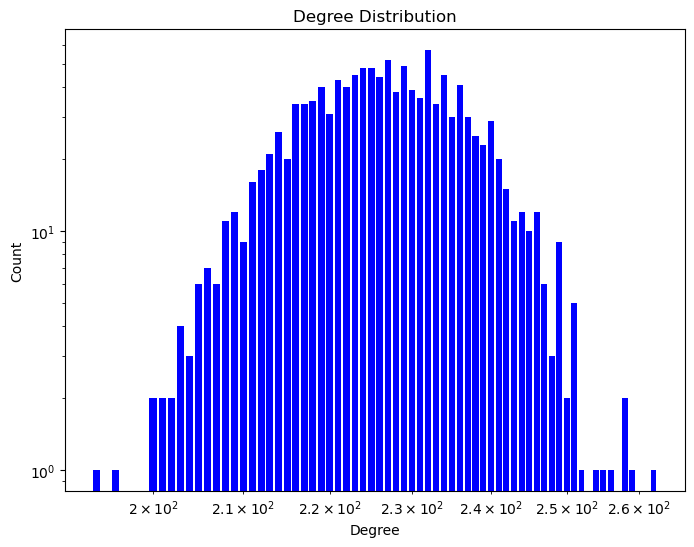

In [117]:
plot_degree_distribution(A)

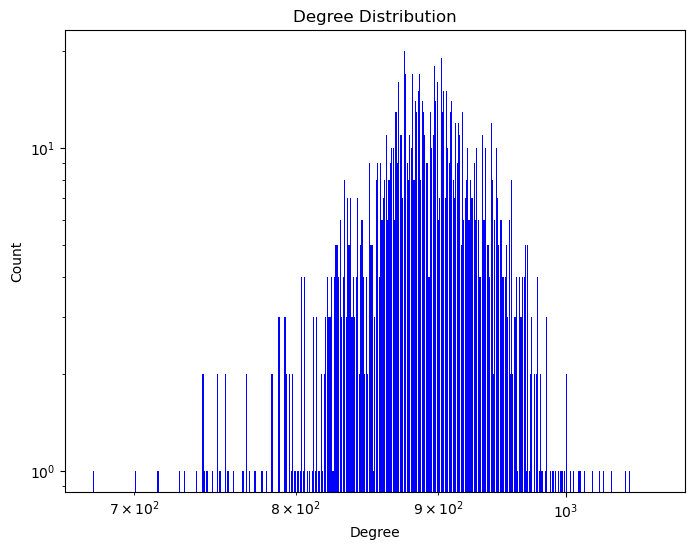

In [118]:
plot_degree_distribution(G)

In [115]:
compute_clustering_coefficient(G)

Average Clustering Coefficient: 0.7172


{0: 0.7168060697472463,
 1: 0.7162451612276518,
 2: 0.7187761787761788,
 3: 0.717685018683603,
 4: 0.7147104709792661,
 5: 0.7164619876788714,
 6: 0.717629359832139,
 7: 0.7173263113808206,
 8: 0.717886097436332,
 9: 0.7158220356292958,
 10: 0.7173637068074172,
 11: 0.717324419165461,
 12: 0.7170438872182151,
 13: 0.717745057394895,
 14: 0.7170983663006466,
 15: 0.7205201255370365,
 16: 0.720008594431314,
 17: 0.7157044558619362,
 18: 0.718152977648038,
 19: 0.7162969991403465,
 20: 0.7185971901154873,
 21: 0.7191992196046031,
 22: 0.7180278409406023,
 23: 0.7204689960916992,
 24: 0.7207054197174944,
 25: 0.7187019669867011,
 26: 0.7178422091274167,
 27: 0.7186320266331098,
 28: 0.718698204801438,
 29: 0.7154175265266282,
 30: 0.7187250489305927,
 31: 0.7205370217331419,
 32: 0.7154121122530276,
 33: 0.7173629704247629,
 34: 0.7174503577304204,
 35: 0.715603792088918,
 36: 0.7165794303582353,
 37: 0.7166568283620959,
 38: 0.717164117958153,
 39: 0.7149819862687785,
 40: 0.7193964124111

In [119]:
compute_clustering_coefficient(A)

Average Clustering Coefficient: 0.1810


{0: 0.1821761334840747,
 1: 0.1811514849842376,
 2: 0.1806243351307729,
 3: 0.18151335191693935,
 4: 0.18088894474466927,
 5: 0.18289325208756488,
 6: 0.1841825318220168,
 7: 0.17941292615506121,
 8: 0.18639752682305874,
 9: 0.17917200512491993,
 10: 0.18196035642844152,
 11: 0.1777150385846038,
 12: 0.17666894508999773,
 13: 0.18041829464490922,
 14: 0.17827764999415227,
 15: 0.1813486370157819,
 16: 0.17675245382177912,
 17: 0.18393524283935242,
 18: 0.18207708372887793,
 19: 0.17780337941628263,
 20: 0.17660130209348562,
 21: 0.18344888301969847,
 22: 0.18494965553789083,
 23: 0.18016186711838886,
 24: 0.17799259563965447,
 25: 0.18409080249519252,
 26: 0.18048250380352096,
 27: 0.18040482342807923,
 28: 0.18362783988460152,
 29: 0.18112033195020746,
 30: 0.176759410801964,
 31: 0.18313797594422737,
 32: 0.1855397821063057,
 33: 0.18417969539045773,
 34: 0.1792132713334171,
 35: 0.18120599938781756,
 36: 0.1815055135978442,
 37: 0.17742379547689283,
 38: 0.18333333333333332,
 39: 0.

In [121]:
compute_average_path_length(G)

Average Path Length: 1.2864


1.286356445156125

In [122]:
compute_average_path_length(A)

Average Path Length: 1.8185


1.8185056845476382

Modularity: 0.0252


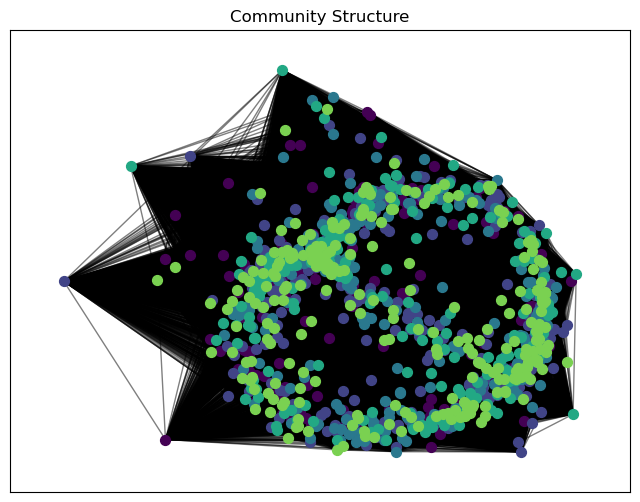

In [125]:
partition = compute_modularity(G)
plot_communities(G, partition)

In [126]:
partition_A = compute_modularity(A)
plot_communities(A, partition_A)

ValueError: Bad node degree (-5856.0)

Analyzing Network Topology...

1. Degree Distribution:


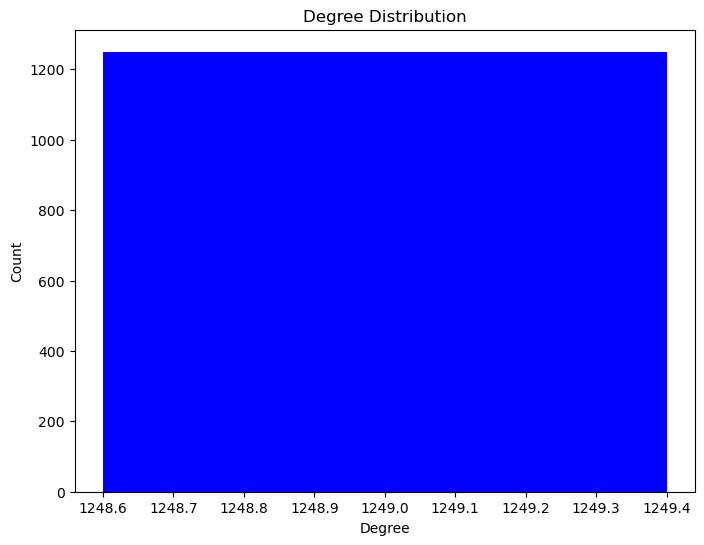


2. Clustering Coefficient:
Average Clustering Coefficient: 1.0000

3. Average Path Length:
Average Path Length: 1.0000

4. Modularity and Community Structure:


NameError: name 'community_louvain' is not defined

In [87]:
analyze_network(G)